# 02 — CRCP Benthic Explorer: Full Pipeline Demo

This notebook runs the complete data pipeline end-to-end:

1. **Ingest** — Query ERDDAP for point-level annotations
2. **Transform** — Aggregate points → images → site-year summaries
3. **Spatial** — Build a GeoDataFrame with validated coordinates
4. **Validate** — Run QA checks at each stage
5. **Export** — Save to GeoJSON for inspection or publishing

This notebook is designed to run both locally and as an ArcGIS Online
Hosted Notebook.

In [1]:
import sys
sys.path.insert(0, "..")

import logging
logging.basicConfig(level=logging.INFO, format="%(name)s — %(message)s")

from src import ingest, transform, spatial, validate

httpx — HTTP Request: GET https://raw.githubusercontent.com/IrishMarineInstitute/awesome-erddap/master/erddaps.json "HTTP/1.1 200 OK"


## Step 1: Ingest from ERDDAP

In [2]:
SOURCE_ID = "hawaii"

points_df = ingest.fetch_source(SOURCE_ID)
print(f"Fetched {len(points_df):,} point annotations")
print(f"Columns: {list(points_df.columns)}")
points_df.head(3)

src.ingest — Fetching Hawaiian Archipelago (dataset=CRCP_Benthic_Cover_Hawaii) with constraints=none
httpx — HTTP Request: GET https://www.ncei.noaa.gov/erddap/tabledap/CRCP_Benthic_Cover_Hawaii.csvp?latitude%2Clongitude%2Cmissionid%2Cregion_name%2Cisland%2Csite%2Creef_zone%2Csurvey_type%2Cdepth_bin%2Cmin_depth%2Cmax_depth%2Cdate_%2Cimage_name%2Cimage_url%2Cobs_year%2Crep%2Cphotoid%2Canalyst%2Ctier_1%2Ccategory_name%2Ctier_2%2Csubcategory_name%2Ctier_3%2Cgenera_name "HTTP/1.1 200 "
src.ingest — Fetched 472070 rows for source 'hawaii'


Fetched 472,070 point annotations
Columns: ['latitude', 'longitude', 'missionid', 'region_name', 'island', 'site', 'reef_zone', 'survey_type', 'depth_bin', 'min_depth', 'max_depth', 'date_', 'image_name', 'image_url', 'obs_year', 'rep', 'photoid', 'analyst', 'tier_1', 'category_name', 'tier_2', 'subcategory_name', 'tier_3', 'genera_name']


,latitude,longitude,missionid,region_name,island,site,reef_zone,survey_type,depth_bin,min_depth,...,obs_year,rep,photoid,analyst,tier_1,category_name,tier_2,subcategory_name,tier_3,genera_name
0,20.069002,-155.391537,SE1902_MHI_LEG1,Main Hawaiian Islands,Hawaii,HAW-3434,Forereef,NaN,Deep,68.0,...,2019,A,1,elooney12,SED,Sediment,SAND,Sand,SAND,Sand
1,20.069002,-155.391537,SE1902_MHI_LEG1,Main Hawaiian Islands,Hawaii,HAW-3434,Forereef,NaN,Deep,68.0,...,2019,A,1,elooney12,SED,Sediment,SAND,Sand,SAND,Sand
2,20.069002,-155.391537,SE1902_MHI_LEG1,Main Hawaiian Islands,Hawaii,HAW-3434,Forereef,NaN,Deep,68.0,...,2019,A,1,elooney12,SED,Sediment,SAND,Sand,SAND,Sand


### Validate raw points

In [3]:
pt_report = validate.validate_points(points_df)
print(pt_report.summary())

src.validate — Validation [points]: 0 issue(s)
  [INFO] All point-level checks passed.


Validation [points]: 0 issue(s)
  [INFO] All point-level checks passed.


## Step 2: Transform — Points to Images

In [4]:
images_df = transform.points_to_images(points_df)
print(f"Image records: {len(images_df):,}")
print(f"Tier-1 cover columns: {[c for c in images_df.columns if c.startswith('t1_')]}")
images_df.head(3)

src.transform — Excluded 1567 TW points (472070 → 470503)
src.transform — Aggregated 470503 points into 46727 image records


Image records: 46,727
Tier-1 cover columns: ['t1_CCA', 't1_CORAL', 't1_I', 't1_MA', 't1_MF', 't1_Other', 't1_SC', 't1_SED', 't1_TURF']


,site,island,region_name,obs_year,reef_zone,depth_bin,min_depth,max_depth,latitude,longitude,...,t3_SHAD,t3_SP,t3_TUN,t3_TURFH,t3_TURFR,t3_UI,t3_UNK,t3_UPMA,t3_USC,t3_ZO
0,FFS-1012,French Frigate,Northwestern Hawaiian Islands,2016,Lagoon,Shallow,NaN,NaN,23.778698,-166.164036,...,0.0,0.0,0.0,90.0,0.0,0.0,0.0,0.0,0.0,0.0
1,FFS-1012,French Frigate,Northwestern Hawaiian Islands,2016,Lagoon,Shallow,NaN,NaN,23.778698,-166.164036,...,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0
2,FFS-1012,French Frigate,Northwestern Hawaiian Islands,2016,Lagoon,Shallow,NaN,NaN,23.778698,-166.164036,...,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0


### Validate image-level data

In [5]:
img_report = validate.validate_images(images_df)
print(img_report.summary())

src.validate — Validation [images]: 0 issue(s)
  [INFO] All image-level checks passed.


Validation [images]: 0 issue(s)
  [INFO] All image-level checks passed.


## Step 3: Transform — Images to Site-Year Summaries

In [6]:
sites_df = transform.images_to_sites(images_df)
print(f"Site-year records: {len(sites_df):,}")
print(f"Islands: {sorted(sites_df['island'].unique())}")
print(f"Years:   {sorted(sites_df['obs_year'].unique())}")
sites_df.head(3)

src.transform — Aggregated 46727 images into 1553 site-year records


Site-year records: 1,553
Islands: ['French Frigate', 'Hawaii', 'Kahoolawe', 'Kauai', 'Kure', 'Lanai', 'Lisianski', 'Maui', 'Molokai', 'Niihau', 'Oahu', 'Pearl & Hermes']
Years:   [2013, 2016, 2019]


,site,obs_year,island,region_name,reef_zone,depth_bin,min_depth,max_depth,latitude,longitude,...,mean_t3_UI,std_t3_UI,mean_t3_UNK,std_t3_UNK,mean_t3_UPMA,std_t3_UPMA,mean_t3_USC,std_t3_USC,mean_t3_ZO,std_t3_ZO
0,FFS-1012,2016,French Frigate,Northwestern Hawaiian Islands,Lagoon,Shallow,NaN,NaN,23.778698,-166.164036,...,0.0,0.0,0.33,1.83,0.0,0.0,0.0,0.0,0.0,0.0
1,FFS-1015,2016,French Frigate,Northwestern Hawaiian Islands,Lagoon,Shallow,NaN,NaN,23.733424,-166.163069,...,0.0,0.0,0.97,3.01,0.0,0.0,0.0,0.0,0.0,0.0
2,FFS-1018,2016,French Frigate,Northwestern Hawaiian Islands,Lagoon,Shallow,NaN,NaN,23.819997,-166.143617,...,0.0,0.0,0.33,1.83,0.0,0.0,0.0,0.0,0.0,0.0


## Step 4: Build GeoDataFrame and validate coordinates

In [7]:
gdf = spatial.build_site_geodataframe(sites_df)
coord_warnings = spatial.validate_coordinates(gdf, SOURCE_ID)

if coord_warnings:
    for w in coord_warnings:
        print(f"  WARNING: {w}")
else:
    print("All coordinates within expected bounds.")

site_report = validate.validate_sites(gdf, expected_images=len(images_df))
print(site_report.summary())

src.spatial — Built GeoDataFrame with 1553 features (CRS=EPSG:4326)
src.spatial — All 1553 features pass coordinate bounds check.
src.validate — Validation [sites]: 0 issue(s)
  [INFO] All site-level checks passed.


All coordinates within expected bounds.
Validation [sites]: 0 issue(s)
  [INFO] All site-level checks passed.


## Step 5: Preview and export

In [8]:
# Quick summary statistics
print(f"Total sites:  {len(gdf):,}")
print(f"Total images: {gdf['n_images'].sum():,}")
print(f"\nMean coral cover by island:")
island_coral = gdf.groupby("island")["mean_t1_CORAL"].mean().sort_values(ascending=False)
for island, val in island_coral.items():
    print(f"  {island:20s} {val:6.1f}%")

Total sites:  1,553
Total images: 46,727

Mean coral cover by island:
  Lanai                  21.3%
  French Frigate         20.4%
  Lisianski              17.1%
  Maui                   16.1%
  Kahoolawe              15.6%
  Hawaii                 13.5%
  Molokai                12.6%
  Oahu                    7.8%
  Kure                    4.9%
  Kauai                   3.4%
  Pearl & Hermes          2.4%
  Niihau                  2.0%


In [9]:
# Export to GeoJSON
from pathlib import Path

output_dir = Path("..") / "data" / "processed"
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / f"{SOURCE_ID}_site_summary.geojson"

gdf.to_file(output_path, driver="GeoJSON")
print(f"Exported to {output_path} ({output_path.stat().st_size / 1024:.0f} KB)")

pyogrio._io — Created 1,553 records


Exported to ../data/processed/hawaii_site_summary.geojson (8327 KB)


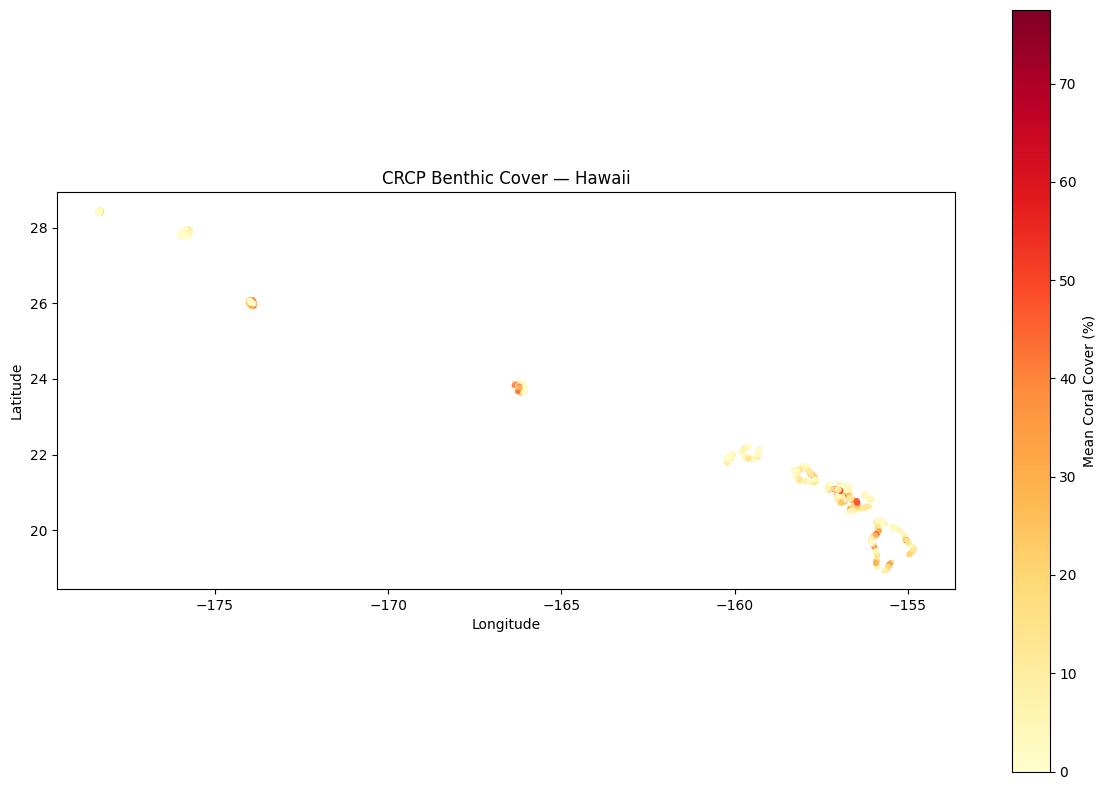

In [10]:
# Simple matplotlib preview
try:
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    gdf.plot(
        ax=ax,
        column="mean_t1_CORAL",
        cmap="YlOrRd",
        legend=True,
        legend_kwds={"label": "Mean Coral Cover (%)"},
        markersize=10,
        alpha=0.7,
    )
    ax.set_title(f"CRCP Benthic Cover — {SOURCE_ID.title()}")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    plt.tight_layout()
    plt.show()
except ImportError:
    print("matplotlib not available — skipping preview plot.")